Saving 1.jpg to 1 (2).jpg
Saving 2.jpg to 2 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


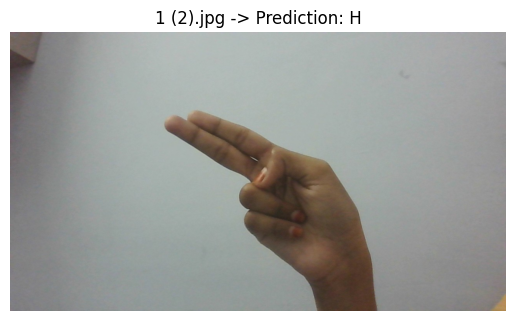

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


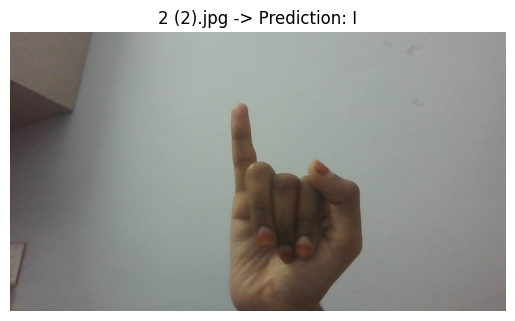

Final Predicted Word: HI


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload multiple images
uploaded = files.upload()

# Sort by filename to keep order 
image_paths = sorted(uploaded.keys())  

IMG_SIZE = 64  

def predict_from_image_path(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = np.expand_dims(img, axis=0).astype('float32') / 255.0
    pred = model.predict(img)
    return label_list[np.argmax(pred)]

# Predict each uploaded image
predicted_letters = []
for path in image_paths:
    letter = predict_from_image_path(path)
    predicted_letters.append(letter)
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f"{path} -> Prediction: {letter}")
    plt.axis('off')
    plt.show()

# Combine letters into word
final_word = ''.join(predicted_letters)
print("Final Predicted Word:", final_word)


In [ ]:
import cv2
import matplotlib.pyplot as plt

def show_signs_for_text_from_kaggle(text):
    text = text.upper()
    for char in text:
        folder = "space" if char == " " else char
        folder_path = os.path.join(ASL_DATASET_PATH, folder)

        if not os.path.exists(folder_path):
            print(f"Folder not found for: {char}")
            continue

        # Pick the first image from the folder
        image_list = os.listdir(folder_path)
        if not image_list:
            print(f"No images in folder: {folder}")
            continue

        image_path = os.path.join(folder_path, image_list[0])
        img = cv2.imread(image_path)
        if img is None:
            print(f"Could not read image: {image_path}")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title(f"Sign for '{char}'")
        plt.axis('off')
        plt.show()



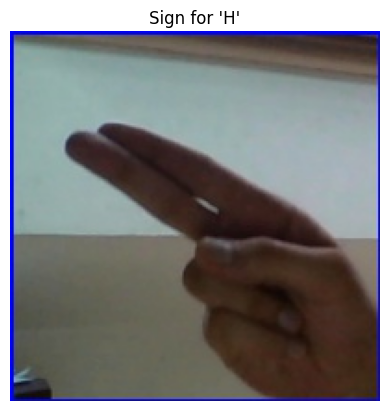

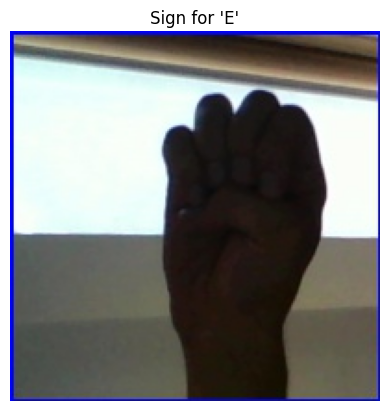

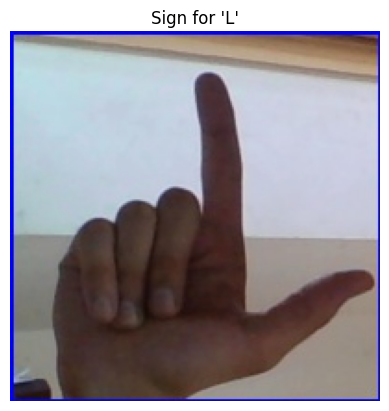

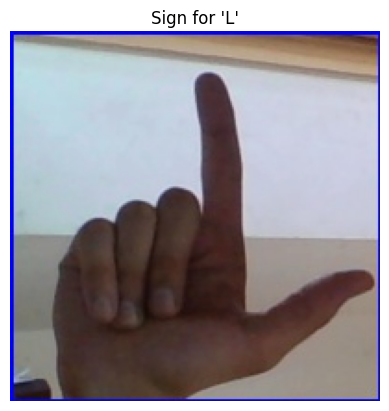

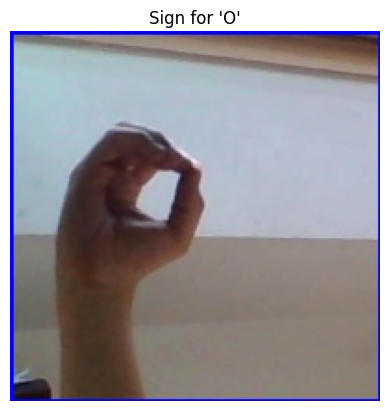

In [ ]:
show_signs_for_text_from_kaggle("HELLO")
